<a href="https://colab.research.google.com/github/gokila-a/Snowflake/blob/main/snowflake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install snowflake-connector-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 3.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found ex

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import snowflake.connector
conn = snowflake.connector.connect(
    user='GOKILA',
    password= 'Btsarmy0739177',
    account= 'TGULZJN-YG81730',
    database= 'HEART',
    schema= 'PUBLIC',
    warehouse= 'COMPUTE_WH'
)

In [ ]:
query = "SELECT * from heart"
df = pd.read_sql(query,conn)
df

/tmp/ipykernel_1454/3694970747.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [ ]:
df.head()

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.tail()

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [ ]:
df.shape

(1025, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AGE       1025 non-null   int64  
 1   SEX       1025 non-null   int64  
 2   CP        1025 non-null   int64  
 3   TRESTBPS  1025 non-null   int64  
 4   CHOL      1025 non-null   int64  
 5   FBS       1025 non-null   int64  
 6   RESTECG   1025 non-null   int64  
 7   THALACH   1025 non-null   int64  
 8   EXANG     1025 non-null   int64  
 9   OLDPEAK   1025 non-null   float64
 10  SLOPE     1025 non-null   int64  
 11  CA        1025 non-null   int64  
 12  THAL      1025 non-null   int64  
 13  TARGET    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.describe()

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
df.isnull().sum()

,0
AGE,0
SEX,0
CP,0
TRESTBPS,0
CHOL,0
FBS,0
RESTECG,0
THALACH,0
EXANG,0
OLDPEAK,0


In [ ]:
from scipy.stats import zscore
z_scores = zscore(df)
df[np.abs(z_scores)>2.5]

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
13,51,1,0,140,298,0,1,122,1,4.2,1,3,3,0
14,52,1,0,128,204,1,1,156,1,1.0,1,0,0,0
29,55,0,0,180,327,0,2,117,1,3.4,1,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,43,1,0,132,247,1,0,143,1,0.1,1,4,3,0
996,56,0,0,134,409,0,0,150,1,1.9,1,2,3,0
1005,55,0,0,128,205,0,2,130,1,2.0,1,1,3,0
1013,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0


In [ ]:
log_transform = np.log1p(df)

print(log_transform.head())

        AGE       SEX   CP  TRESTBPS      CHOL       FBS   RESTECG   THALACH  \
0  3.970292  0.693147  0.0  4.836282  5.361292  0.000000  0.693147  5.129899   
1  3.988984  0.693147  0.0  4.948760  5.318120  0.693147  0.000000  5.049856   
2  4.262680  0.693147  0.0  4.983607  5.164786  0.000000  0.693147  4.836282   
3  4.127134  0.693147  0.0  5.003946  5.318120  0.000000  0.693147  5.087596   
4  4.143135  0.000000  0.0  4.934474  5.686975  0.693147  0.693147  4.672829   

      EXANG   OLDPEAK     SLOPE        CA      THAL  TARGET  
0  0.000000  0.693147  1.098612  1.098612  1.386294     0.0  
1  0.693147  1.410987  0.000000  0.000000  1.386294     0.0  
2  0.693147  1.280934  0.000000  0.000000  1.386294     0.0  
3  0.000000  0.000000  1.098612  0.693147  1.386294     0.0  
4  0.000000  1.064711  0.693147  1.386294  1.098612     0.0  


In [ ]:
from scipy.stats import zscore
z_scores = zscore(df)
df[np.abs(z_scores)>2.5]

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
13,51,1,0,140,298,0,1,122,1,4.2,1,3,3,0
14,52,1,0,128,204,1,1,156,1,1.0,1,0,0,0
29,55,0,0,180,327,0,2,117,1,3.4,1,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,43,1,0,132,247,1,0,143,1,0.1,1,4,3,0
996,56,0,0,134,409,0,0,150,1,1.9,1,2,3,0
1005,55,0,0,128,205,0,2,130,1,2.0,1,1,3,0
1013,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)

In [ ]:
X = log_transform.drop("TARGET", axis=1)

# Use original TARGET column (not log transformed)
y = df["TARGET"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)

In [ ]:
dt_model.fit(X_train, y_train)

# Prediction
y_pred = dt_model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.7902439024390244

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.70      0.77       102
           1       0.75      0.88      0.81       103

    accuracy                           0.79       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.79      0.79       205



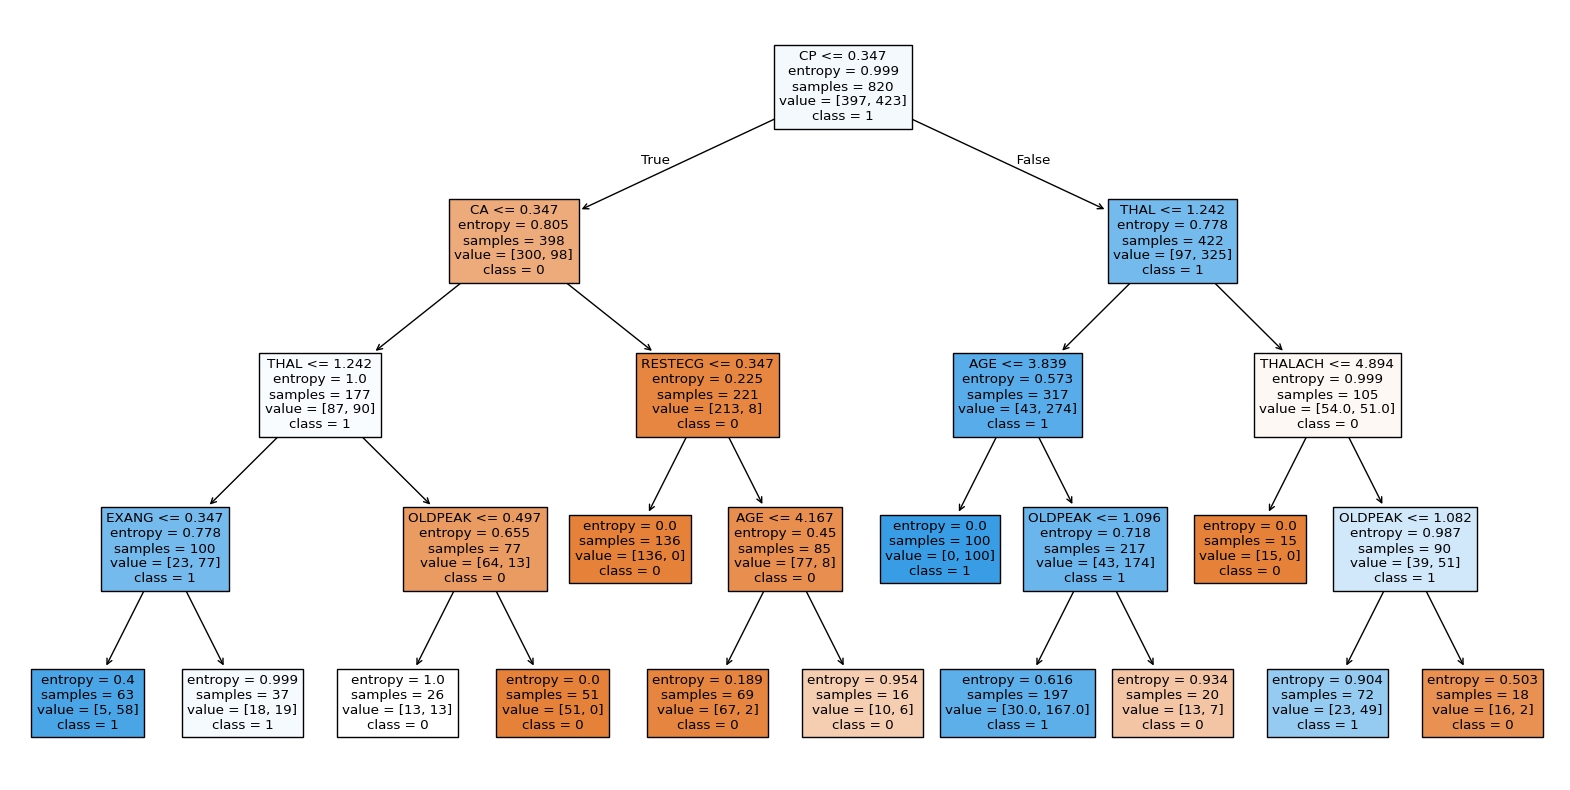

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['0', '1'],
    filled=True
)

plt.show()